In [5]:
# ============================================================
# AI Innovators Lab: Rock-Paper-Scissors Classifier
# ============================================================
# This project teaches an AI model to recognize three hand gestures.
# The three possible gestures are rock, paper, and scissors.
# The model will look at an image and choose which gesture it thinks is shown.
# This is an image classification problem because the AI places each image into one class.
# A class means a category, such as "rock", "paper", or "scissors".
# We will train a CNN, which is a type of AI model commonly used for images.
# CNN stands for Convolutional Neural Network.
# A CNN learns visual patterns such as edges, shapes, and textures.
# In this project, the CNN learns patterns that help separate rock, paper, and scissors.
# The input to the model is a hand gesture image.
# The output from the model is the predicted gesture name.
# The dataset comes from TensorFlow's Rock Paper Scissors image dataset.
# Dataset page: https://www.tensorflow.org/datasets/catalog/rock_paper_scissors
# Students will train the model and then upload their own image to test it.
# ============================================================

# Print a welcome message so students know the notebook has started.
print("Welcome to the Rock-Paper-Scissors AI Project!")

# Print the main goal of the project in simple language.
print("Goal: Build an AI model that can recognize rock, paper, and scissors hand gestures.")


Welcome to the Rock-Paper-Scissors AI Project!
Goal: Build an AI model that can recognize rock, paper, and scissors hand gestures.


In [6]:
# ============================================================
# Step 1: Import libraries
# ============================================================
# A library is a collection of helpful code written by other programmers.
# We import libraries so we do not have to write everything from scratch.

# Import os so Python can work with folders and file paths.
import os

# Import zipfile so Python can open and extract compressed .zip files.
import zipfile

# Import shutil so Python can delete folders and copy files when needed.
import shutil

# Import urllib.request so Python can download files from the internet.
import urllib.request

# Import NumPy, a library used for working with numbers and arrays.
import numpy as np

# Import matplotlib so we can display images and draw graphs.
import matplotlib.pyplot as plt

# Import TensorFlow, the main AI/deep learning library used in this project.
import tensorflow as tf

# Import layers and models from Keras, which helps us build neural networks.
from tensorflow.keras import layers, models

# Import ImageDataGenerator to load images from folders and prepare them for training.
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Import image tools so we can load and prepare a single uploaded image later.
from tensorflow.keras.preprocessing import image

# Import files from Google Colab so students can upload their own image.
from google.colab import files

# Print a message to confirm that all libraries loaded without errors.
print("Libraries loaded successfully!")


Libraries loaded successfully!


In [7]:
# ============================================================
# Step 2: Download the dataset
# ============================================================
# A dataset is a collection of examples used to train and test an AI model.
# In this project, the dataset contains images of rock, paper, and scissors gestures.
# The training dataset teaches the model.
# The testing dataset checks how well the model learned.

# Store the internet link for the training image zip file.
train_url = "https://storage.googleapis.com/download.tensorflow.org/data/rps.zip"

# Store the internet link for the testing image zip file.
test_url = "https://storage.googleapis.com/download.tensorflow.org/data/rps-test-set.zip"

# Choose the filename for the downloaded training zip file.
train_zip = "rps.zip"

# Choose the filename for the downloaded testing zip file.
test_zip = "rps-test-set.zip"

# Choose the main folder where all dataset files will be stored.
base_dir = "rock_paper_scissors_dataset"

# Create the path for the training folder inside the main dataset folder.
train_dir = os.path.join(base_dir, "train")

# Create the path for the testing folder inside the main dataset folder.
test_dir = os.path.join(base_dir, "test")

# Check whether the dataset folder already exists from a previous run.
if os.path.exists(base_dir):
    # Delete the old dataset folder so we start fresh and avoid mixed files.
    shutil.rmtree(base_dir)

# Create the training folder; exist_ok=True prevents an error if it already exists.
os.makedirs(train_dir, exist_ok=True)

# Create the testing folder; exist_ok=True prevents an error if it already exists.
os.makedirs(test_dir, exist_ok=True)

# Tell students that the notebook is downloading the training images.
print("Downloading training images...")

# Download the training zip file from the internet and save it as rps.zip.
urllib.request.urlretrieve(train_url, train_zip)

# Tell students that the notebook is downloading the testing images.
print("Downloading testing images...")

# Download the testing zip file from the internet and save it as rps-test-set.zip.
urllib.request.urlretrieve(test_url, test_zip)

# Print a success message after both downloads finish.
print("Dataset downloaded successfully!")


Dataset downloaded successfully!


In [8]:
# ============================================================
# Step 3: Extract the dataset
# ============================================================
# The downloaded files are zip files, which means the images are compressed.
# We need to extract the zip files before Python can use the images.

# Open the training zip file in read mode.
with zipfile.ZipFile(train_zip, "r") as zip_ref:
    # Extract all training images into the training folder.
    zip_ref.extractall(train_dir)

# Open the testing zip file in read mode.
with zipfile.ZipFile(test_zip, "r") as zip_ref:
    # Extract all testing images into the testing folder.
    zip_ref.extractall(test_dir)

# Print a message to confirm that extraction is complete.
print("Dataset extracted successfully!")

# After extraction, the training images are inside a folder named "rps".
train_data_dir = os.path.join(train_dir, "rps")

# After extraction, the testing images are inside a folder named "rps-test-set".
test_data_dir = os.path.join(test_dir, "rps-test-set")

# Show the exact folder path where the training images are stored.
print("Training folder:", train_data_dir)

# Show the exact folder path where the testing images are stored.
print("Testing folder:", test_data_dir)

# Print a blank line, then show the class folders in the training dataset.
print("\nTraining classes:", os.listdir(train_data_dir))

# Show the class folders in the testing dataset.
print("Testing classes:", os.listdir(test_data_dir))


Dataset extracted successfully!
Training folder: rock_paper_scissors_dataset/train/rps
Testing folder: rock_paper_scissors_dataset/test/rps-test-set

Training classes: ['rock', 'paper', 'scissors']
Testing classes: ['rock', 'paper', 'scissors']


rock
  Training images: 840
  Testing images: 124
paper
  Training images: 840
  Testing images: 124
scissors
  Training images: 840
  Testing images: 124


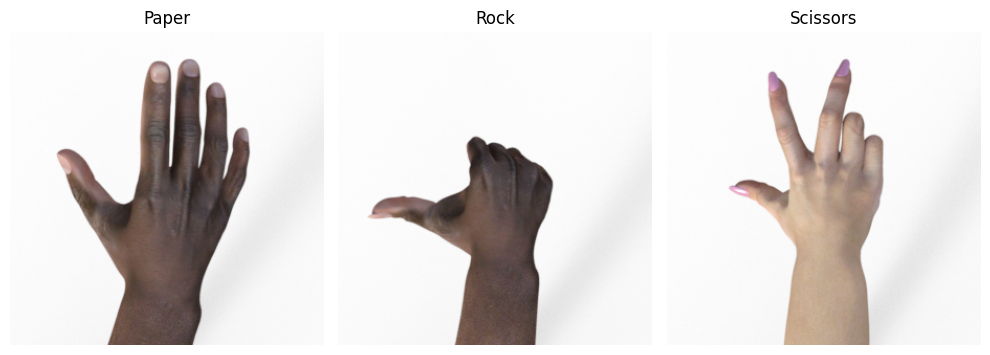

In [9]:
# ============================================================
# Step 4: Count images
# ============================================================
# Before training, it is useful to check how many images we have.
# Each class should have images so the model can learn examples of that gesture.

# Go through the three gesture classes one at a time.
for class_name in ["rock", "paper", "scissors"]:
    # Count how many training images are inside this class folder.
    train_count = len(os.listdir(os.path.join(train_data_dir, class_name)))

    # Count how many testing images are inside this class folder.
    test_count = len(os.listdir(os.path.join(test_data_dir, class_name)))

    # Print the class name, such as rock, paper, or scissors.
    print(class_name)

    # Print the number of training images for this class.
    print("  Training images:", train_count)

    # Print the number of testing images for this class.
    print("  Testing images:", test_count)

# ============================================================
# Step 5: Show sample images
# ============================================================
# We display one image from each class so students can see what the data looks like.

# Store the class names in the order we want to display them.
class_names = ["paper", "rock", "scissors"]

# Create a figure area that will hold the sample images.
plt.figure(figsize=(10, 6))

# Start counting image positions at 1 because matplotlib subplot positions start at 1.
image_number = 1

# Go through each class name in the list.
for class_name in class_names:
    # Build the path to the folder for the current class.
    folder = os.path.join(train_data_dir, class_name)

    # Pick the first image file from this class folder as a sample.
    sample_file = os.listdir(folder)[0]

    # Build the full path to the sample image file.
    sample_path = os.path.join(folder, sample_file)

    # Read the image from the file so matplotlib can display it.
    img = plt.imread(sample_path)

    # Create a subplot with 1 row, 3 columns, and place the image in the current position.
    plt.subplot(1, 3, image_number)

    # Display the image.
    plt.imshow(img)

    # Add a title above the image using the class name.
    plt.title(class_name.capitalize())

    # Hide the x-axis and y-axis numbers because they are not needed for images.
    plt.axis("off")

    # Move to the next subplot position.
    image_number += 1

# Adjust spacing so the images and titles do not overlap.
plt.tight_layout()

# Show the final figure on the screen.
plt.show()


In [10]:
# ============================================================
# Step 6: Prepare images for training
# ============================================================
# The model cannot directly understand image files the way humans do.
# We must resize images and turn pixel values into numbers the model can learn from.
# We also use data augmentation, which creates slightly changed versions of images.
# This helps the model learn better by seeing different rotations, shifts, and zooms.

# Set the image width and height to 150 pixels.
IMG_SIZE = 150

# Set how many images the model will look at before updating its learning.
BATCH_SIZE = 32

# Create a training image generator.
# This loads images from folders and also creates small random changes to help learning.
train_datagen = ImageDataGenerator(
    # Change pixel values from 0-255 to 0-1 so the model trains more smoothly.
    rescale=1.0 / 255,

    # Randomly rotate images up to 20 degrees.
    rotation_range=20,

    # Randomly move images left or right by up to 10% of the image width.
    width_shift_range=0.1,

    # Randomly move images up or down by up to 10% of the image height.
    height_shift_range=0.1,

    # Randomly zoom in or out by up to 20%.
    zoom_range=0.2,

    # Randomly flip images horizontally so the model sees more variety.
    horizontal_flip=True
)

# Create a testing image generator.
# Testing images should only be rescaled, not randomly changed.
test_datagen = ImageDataGenerator(
    # Change pixel values from 0-255 to 0-1.
    rescale=1.0 / 255
)

# Load training images from the training folder.
train_generator = train_datagen.flow_from_directory(
    # This is the folder that contains rock, paper, and scissors subfolders.
    train_data_dir,

    # Resize every image to 150 by 150 pixels.
    target_size=(IMG_SIZE, IMG_SIZE),

    # Load 32 images at a time.
    batch_size=BATCH_SIZE,

    # Use categorical labels because we have three classes.
    class_mode="categorical"
)

# Load testing images from the testing folder.
test_generator = test_datagen.flow_from_directory(
    # This is the folder that contains testing images for each class.
    test_data_dir,

    # Resize every testing image to the same size as the training images.
    target_size=(IMG_SIZE, IMG_SIZE),

    # Load 32 testing images at a time.
    batch_size=BATCH_SIZE,

    # Use categorical labels because the answer can be rock, paper, or scissors.
    class_mode="categorical",

    # Keep the testing images in order so predictions match the correct labels.
    shuffle=False
)

# Print a message confirming that image preparation is complete.
print("Images are ready for training!")

# Print the number assigned to each class, such as paper: 0, rock: 1, scissors: 2.
print("Class labels:", train_generator.class_indices)


Found 2520 images belonging to 3 classes.
Found 372 images belonging to 3 classes.
Images are ready for training!
Class labels: {'paper': 0, 'rock': 1, 'scissors': 2}


In [11]:
# ============================================================
# Step 7: Build the AI model
# ============================================================
# We will build a Convolutional Neural Network, or CNN.
# A CNN is good for images because it can learn visual patterns.
# Early layers learn simple patterns such as edges.
# Later layers learn more complex patterns such as hand shapes.

# Create a model where layers are stacked one after another in order.
model = models.Sequential([
    # Define the shape of one input image.
    # IMG_SIZE by IMG_SIZE means 150 by 150 pixels.
    # The 3 means each pixel has three color channels: red, green, and blue.
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    # First convolution layer.
    # It learns 32 small visual filters, each looking at 3 by 3 pixel areas.
    # ReLU keeps useful positive values and turns negative values into 0.
    layers.Conv2D(32, (3, 3), activation="relu"),

    # Max pooling makes the image information smaller while keeping important patterns.
    # This helps the model train faster and focus on strong features.
    layers.MaxPooling2D(2, 2),

    # Second convolution layer.
    # It learns 64 filters, so it can detect more patterns than the first layer.
    layers.Conv2D(64, (3, 3), activation="relu"),

    # Pool again to reduce the size of the feature maps.
    layers.MaxPooling2D(2, 2),

    # Third convolution layer.
    # It learns 128 filters, which can detect more detailed hand gesture patterns.
    layers.Conv2D(128, (3, 3), activation="relu"),

    # Pool again to keep the strongest visual patterns.
    layers.MaxPooling2D(2, 2),

    # Flatten changes the 2D image pattern information into one long list of numbers.
    # Dense layers need a one-dimensional list as input.
    layers.Flatten(),

    # Dense layer with 128 neurons.
    # This layer combines the learned visual patterns to make a decision.
    layers.Dense(128, activation="relu"),

    # Dropout randomly turns off some neurons during training.
    # This helps prevent memorizing and encourages better general learning.
    layers.Dropout(0.5),

    # Final output layer with 3 neurons because there are 3 classes.
    # Softmax turns the outputs into probabilities that add up to 1.
    layers.Dense(3, activation="softmax")
])

# Compile means prepare the model for training.
model.compile(
    # Adam is the learning method that updates the model to improve predictions.
    optimizer="adam",

    # Categorical crossentropy measures how wrong the model is for multi-class problems.
    loss="categorical_crossentropy",

    # Accuracy tells us the percent of images the model predicts correctly.
    metrics=["accuracy"]
)

# Print a summary showing all model layers and the number of trainable parameters.
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,739 (18.42 MB)

 Trainable params: 4,828,739 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# ============================================================
# Step 8: Train the model
# ============================================================
# Training means showing the model many labeled images.
# The model makes predictions, checks mistakes, and updates itself to improve.
# One epoch means the model has gone through the training dataset one full time.

# Train the model and save the training history.
history = model.fit(
    # Use the prepared training images and labels.
    train_generator,

    # Train for 5 epochs.
    # More epochs can improve learning, but too many may cause memorization.
    epochs=5,

    # Use the testing images during training to check how well the model generalizes.
    validation_data=test_generator
)

# Print a message after training finishes.
print("Model training completed!")


Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.5595 - loss: 0.9022 - val_accuracy: 0.9086 - val_loss: 0.4223
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.8464 - loss: 0.4000 - val_accuracy: 0.9462 - val_loss: 0.1681
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 148s 2s/step - accuracy: 0.9083 - loss: 0.2620 - val_accuracy: 0.9624 - val_loss: 0.0858
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.9409 - loss: 0.1718 - val_accuracy: 0.9973 - val_loss: 0.0580
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.9619 - loss: 0.1388 - val_accuracy: 0.9785 - val_loss: 0.0762
Model training completed!


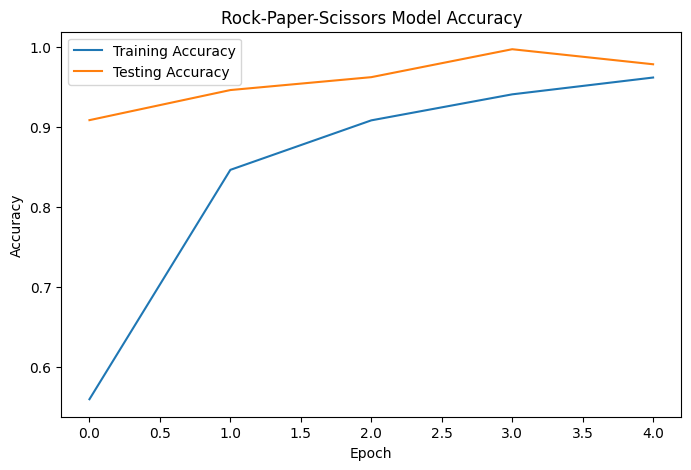

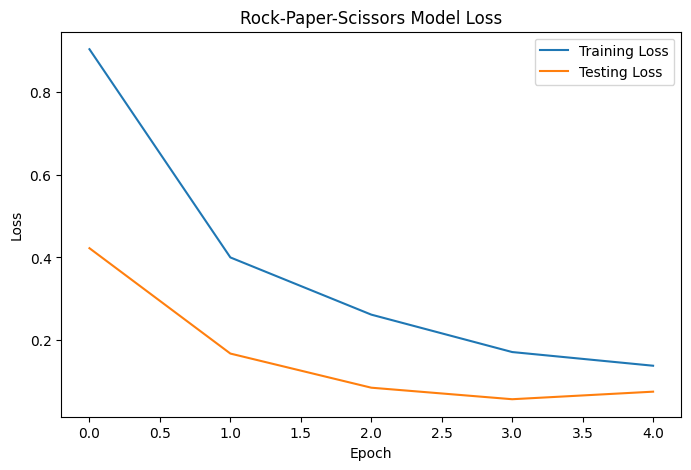

In [13]:
# ============================================================
# Step 9: Plot accuracy and loss
# ============================================================
# Accuracy shows how often the model is correct.
# Loss shows how much error the model still has.
# Usually, we want accuracy to go up and loss to go down.

# Create a new figure for the accuracy graph.
plt.figure(figsize=(8, 5))

# Plot the training accuracy from each epoch.
plt.plot(history.history["accuracy"], label="Training Accuracy")

# Plot the testing accuracy from each epoch.
plt.plot(history.history["val_accuracy"], label="Testing Accuracy")

# Add a title to the graph.
plt.title("Rock-Paper-Scissors Model Accuracy")

# Label the x-axis as epoch number.
plt.xlabel("Epoch")

# Label the y-axis as accuracy.
plt.ylabel("Accuracy")

# Show a legend explaining which line is training and which line is testing.
plt.legend()

# Display the accuracy graph.
plt.show()

# Create a new figure for the loss graph.
plt.figure(figsize=(8, 5))

# Plot the training loss from each epoch.
plt.plot(history.history["loss"], label="Training Loss")

# Plot the testing loss from each epoch.
plt.plot(history.history["val_loss"], label="Testing Loss")

# Add a title to the graph.
plt.title("Rock-Paper-Scissors Model Loss")

# Label the x-axis as epoch number.
plt.xlabel("Epoch")

# Label the y-axis as loss.
plt.ylabel("Loss")

# Show a legend explaining which line is training and which line is testing.
plt.legend()

# Display the loss graph.
plt.show()


In [14]:
# ============================================================
# Step 10: Evaluate the model
# ============================================================
# Evaluation tests the finished model on images it did not train on.
# This helps us estimate how well the model works on new images.

# Evaluate the model using the testing image generator.
test_loss, test_accuracy = model.evaluate(test_generator)

# Print the final test accuracy as a percentage.
print("Test Accuracy:", round(test_accuracy * 100, 2), "%")


12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 529ms/step - accuracy: 0.9785 - loss: 0.0762
Test Accuracy: 97.85 %


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step


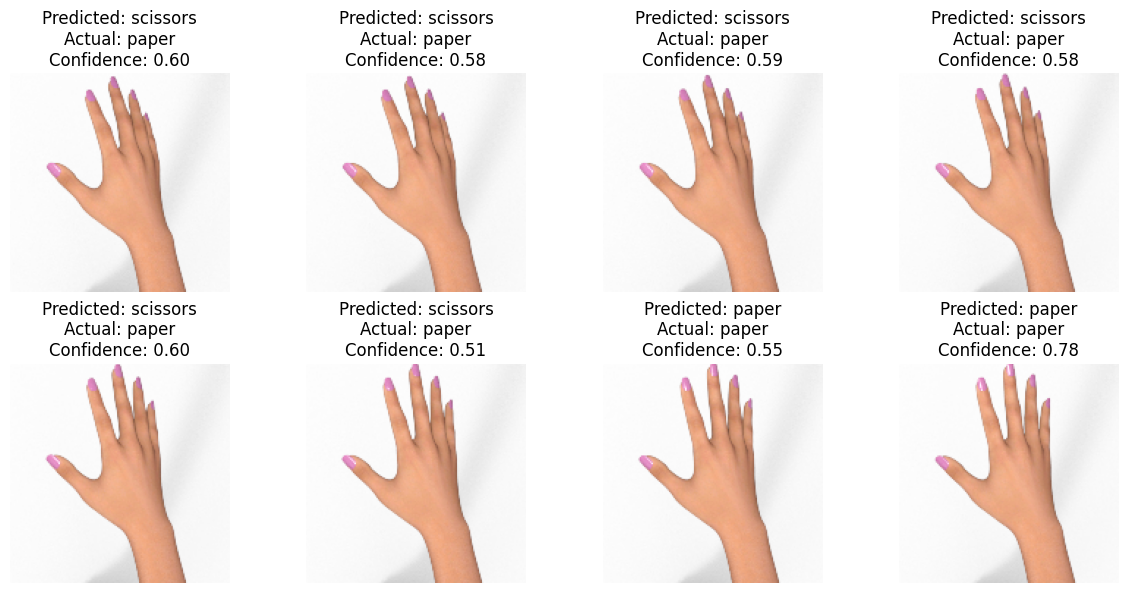

In [15]:
# ============================================================
# Step 11: Show predictions
# ============================================================
# In this step, we show some testing images and the model's predictions.
# This helps students visually check what the AI is doing.

# Get the dictionary that maps class names to number labels.
class_indices = train_generator.class_indices

# Reverse the dictionary so we can convert number labels back to class names.
index_to_class = {value: key for key, value in class_indices.items()}

# Get one batch of testing images and their correct labels.
test_images, test_labels = next(test_generator)

# Ask the model to predict the class probabilities for these testing images.
predictions = model.predict(test_images)

# Create a figure area for displaying multiple prediction examples.
plt.figure(figsize=(12, 6))

# Show the first 8 images from the testing batch.
for i in range(8):
    # Find the class number with the highest predicted probability.
    predicted_index = np.argmax(predictions[i])

    # Find the actual correct class number from the true label.
    actual_index = np.argmax(test_labels[i])

    # Find the highest probability value, which shows the model's confidence.
    confidence = np.max(predictions[i])

    # Convert the predicted class number into a class name.
    predicted_class = index_to_class[predicted_index]

    # Convert the actual class number into a class name.
    actual_class = index_to_class[actual_index]

    # Create a subplot with 2 rows and 4 columns.
    plt.subplot(2, 4, i + 1)

    # Display the testing image.
    plt.imshow(test_images[i])

    # Add a title showing prediction, correct answer, and confidence.
    plt.title(
        f"Predicted: {predicted_class}\n"
        f"Actual: {actual_class}\n"
        f"Confidence: {confidence:.2f}"
    )

    # Hide axis numbers because they are not helpful for viewing images.
    plt.axis("off")

# Adjust the layout so titles and images fit nicely.
plt.tight_layout()

# Show the prediction examples.
plt.show()


Upload your own rock, paper, or scissors image.


Saving Rock Paper Scissors 1.jpeg to Rock Paper Scissors 1.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


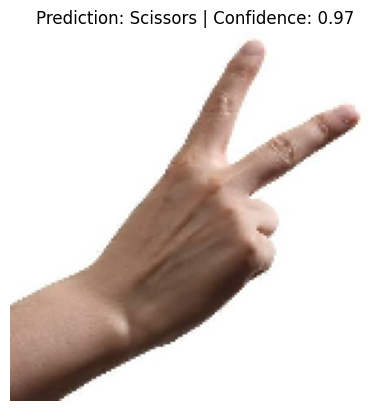

The AI thinks this is: Scissors
Confidence: 97.1 %


In [19]:
# ============================================================
# Step 12: Upload your own image
# ============================================================
# Now students can upload their own rock, paper, or scissors image.
# The model will prepare the image in the same way as the training images.
# Then it will predict which gesture is shown.

# Print instructions for the student.
print("Upload your own rock, paper, or scissors image.")

# Open a file upload button in Google Colab.
uploaded = files.upload()

# Go through each uploaded file.
for filename in uploaded.keys():
    # Load the uploaded image and resize it to 150 by 150 pixels.
    img = image.load_img(filename, target_size=(IMG_SIZE, IMG_SIZE))

    # Convert the image into a NumPy array of pixel numbers.
    img_array = image.img_to_array(img)

    # Rescale pixel values from 0-255 to 0-1, just like the training images.
    img_array = img_array / 255.0

    # Add one extra dimension because the model expects a batch of images.
    # Even though we upload one image, the model still expects shape: number_of_images, height, width, colors.
    img_array = np.expand_dims(img_array, axis=0)

    # Ask the model to predict probabilities for the uploaded image.
    # [0] gets the prediction for the first and only image in the batch.
    prediction = model.predict(img_array)[0]

    # Find the class number with the highest probability.
    predicted_index = np.argmax(prediction)

    # Convert the predicted class number into the class name.
    predicted_class = index_to_class[predicted_index]

    # Get the probability value for the predicted class.
    confidence = prediction[predicted_index]

    # Display the uploaded image.
    plt.imshow(img)

    # Hide axis numbers around the image.
    plt.axis("off")

    # Add a title with the prediction and confidence score.
    plt.title(
        f"Prediction: {predicted_class.capitalize()} | "
        f"Confidence: {confidence:.2f}"
    )

    # Show the uploaded image with the prediction title.
    plt.show()

    # Print the predicted class in a student friendly sentence.
    print("The AI thinks this is:", predicted_class.capitalize())

    # Print the confidence as a percentage.
    print("Confidence:", round(confidence * 100, 2), "%")


In [20]:
# ============================================================
# Step 13: Save the model
# ============================================================
# Saving the model lets us use it again later without retraining from the beginning.
# The .keras file stores the model structure and the learned weights.

# Save the trained model to a file.
model.save("rock_paper_scissors_model.keras")

# Print a message that tells students the model was saved successfully.
print("Model saved as rock_paper_scissors_model.keras")


Model saved as rock_paper_scissors_model.keras


In [21]:
# ============================================================
# Step 14: Reflection questions
# ============================================================
# These questions help students explain what they built and what they learned.
# Reflection is important because AI is not just about running code.
# Students should understand the problem, data, model, results, and limitations.

# Store the reflection questions in a Python list.
reflection_questions = [
    # Ask students to describe the main goal of the project.
    "1. What problem does your AI model solve?",

    # Ask students to identify the dataset used for training and testing.
    "2. What dataset did you use?",

    # Ask students to name the three output classes.
    "3. What are the three classes your model predicts?",

    # Ask students to explain learning from labeled image examples.
    "4. How did the AI learn from hand gesture images?",

    # Ask students to record their final model accuracy.
    "5. What was your model accuracy?",

    # Ask students to think about incorrect predictions.
    "6. Did the model make any mistakes?",

    # Ask students to reason about why some images may be difficult.
    "7. Why might some hand gestures be difficult to classify?",

    # Ask students to connect gesture recognition to real-world applications.
    "8. How could gesture recognition be used in real life?",

    # Ask students to suggest ways to improve the model.
    "9. How could this model be improved?"
]

# Print a heading before displaying the questions.
print("\nReflection Questions:")

# Go through each question in the list.
for question in reflection_questions:
    # Print the current reflection question.
    print(question)



Reflection Questions:
1. What problem does your AI model solve?
2. What dataset did you use?
3. What are the three classes your model predicts?
4. How did the AI learn from hand gesture images?
5. What was your model accuracy?
6. Did the model make any mistakes?
7. Why might some hand gestures be difficult to classify?
8. How could gesture recognition be used in real life?
9. How could this model be improved?


In [ ]:
# ============================================================
# Presentation Template for Students
# ============================================================
# This cell gives students a simple presentation outline.
# Students can copy this template and fill in their own results.
# The goal is to help students explain their AI project clearly.

# Store the full presentation template as a multi-line string.
presentation_template = """
Project Title:
Rock-Paper-Scissors AI Classifier

Team Members:
[Names]

Problem:
We wanted to build an AI model that can recognize hand gestures for rock, paper, and scissors.

Dataset:
We used the TensorFlow Datasets Rock Paper Scissors dataset.

Dataset Link:
https://www.tensorflow.org/datasets/catalog/rock_paper_scissors

Input:
Image of a hand gesture

Prediction:
Rock, Paper, or Scissors

Model Used:
Convolutional Neural Network (CNN)

Result:
Our model reached approximately ____% accuracy.

Demo:
We uploaded a hand gesture image, and the model predicted rock, paper, or scissors.

What We Learned:
We learned how AI can classify images using labeled training data.

Real-World Use:
Gesture recognition can be used in games, accessibility tools, sign-language support, and human-computer interaction.

Future Improvement:
We could train with more real hand images, different backgrounds, and more hand gestures.
"""

# Print the presentation template so students can see it in the notebook output.
print(presentation_template)
